In [7]:
import os

os.listdir("../../data")


['.amlignore',
 '.amlignore.amltmp',
 '.ipynb_checkpoints',
 'dataset_final_modelo.csv',
 'g1tfm-test-dataset-complete.csv',
 'g1tfm-test-dataset-manipulated.csv',
 'g1tfm-test-dataset.csv']

In [24]:
#Importar libreria para manejo de datos
import pandas as pd

#Leer archivo de datos reales
# ../.. sube a 3 niveles del archivo donde se ejecuta
df = pd.read_csv("../../data/dataset_final_modelo_10k.csv")
#Imprimir primeras lineas para visualizar data
df.head()


,DUI_clean,edad,ingresos_declarados,nivel_endeudamiento,utilizacion_tarjetas,score_buro,morosidad_prev,historial_empresa,consumo_electrico,pago_serv_publicos,titularidad_serv_publico,remesas,ingresos_bancarios,ultimo_consumo_movil,pago,portabilidad
0,36787389,39,1050.00,0.1711,0.50,513,-5,0,244,1,0,0,675.565004,20,1,1
1,57164229,27,1282.97,0.0000,0.00,0,0,0,350,1,0,300,680.624401,45,0,1
2,49908245,31,425.00,0.0000,0.05,407,0,0,50,1,1,300,458.719195,10,0,1
3,20495348,57,0.00,0.0000,0.00,0,0,0,381,1,1,200,1268.834535,7,0,0
4,26590837,64,0.00,0.0000,0.00,0,0,0,147,1,1,100,318.198118,44,0,1


In [25]:
#Eliminar DUI Clean
df = df.drop(columns=["DUI_clean"])

#Remover la variable de resultado del data set para crear variable X
X = df.drop("pago", axis=1)

#Definiiendo variable y como la columna de pago
y = df["pago"]

df.head()
print(len(df))

10000


In [26]:
#Importar libreria auxiliar para ML
from sklearn.model_selection import train_test_split

#Dividir el dataset en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [27]:
import warnings
warnings.filterwarnings("ignore")
#Importar el algoritmo seleccionado
#Se selecciono este algoritmo al ser el que presenta mejores resultados en un entranamiento de autoML
from xgboost import XGBClassifier

#Configuración de hyperparametros del algortimo
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"   # ← THIS REMOVES THE WARNING
)


model.fit(X_train, y_train)

model

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.8,
              enable_categorical=False, eval_metric='logloss', gamma=0,
              gpu_id=-1, importance_type=None, interaction_constraints='',
              learning_rate=0.1, max_delta_step=0, max_depth=5,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=200, n_jobs=4, num_parallel_tree=1, predictor='auto',
              random_state=42, reg_alpha=0, reg_lambda=1, scale_pos_weight=1,
              subsample=0.8, tree_method='exact', validate_parameters=1,
              verbosity=None)

In [28]:
#Se importan librerias auxiliares para metricas
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

#se corren los modelos
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

#Impresion de metricas
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7033333333333334
F1: 0.21099290780141844
AUC: 0.6735075450138845

Classification report:
               precision    recall  f1-score   support

           0       0.71      0.96      0.82      2069
           1       0.60      0.13      0.21       931

    accuracy                           0.70      3000
   macro avg       0.66      0.55      0.51      3000
weighted avg       0.68      0.70      0.63      3000



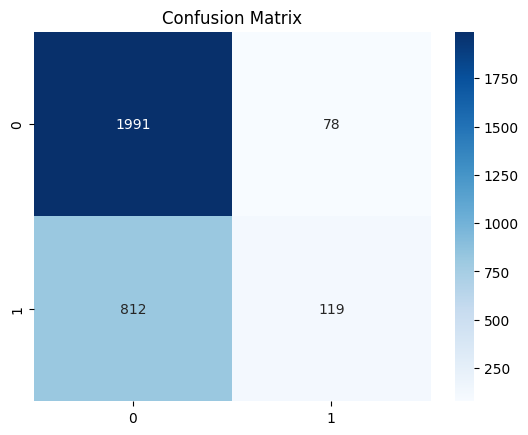

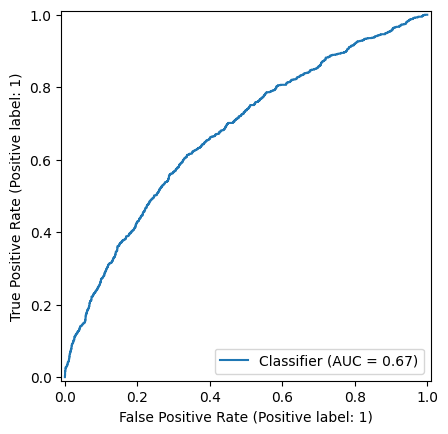

In [29]:
#Importar librerias para metricas visuales
from sklearn.metrics import confusion_matrix, RocCurveDisplay
import seaborn as sns
#Libreria de diagramación
import matplotlib.pyplot as plt

#Creación de matriz de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.show()

#Creación de Curva ROC
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.show()


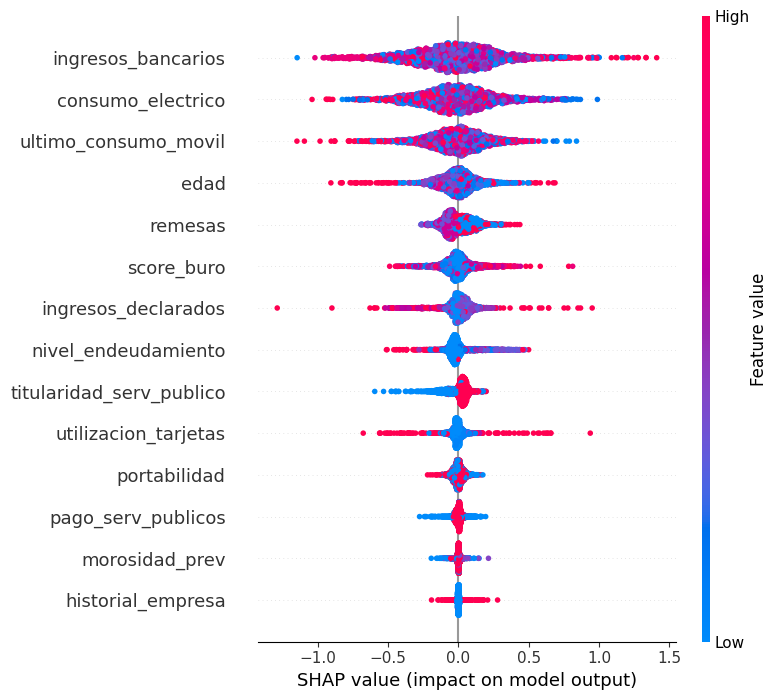

In [32]:
#Importar libreria que explica el modelo
#SHAP analiza tu modelo árbol‐basado (XGBoost) y calcula la contribución de cada variable a las predicciones.
import shap

#Explica el modelo basado en arboles
explainer = shap.TreeExplainer(model)
#Muestra ¿Cuánto contribuyó cada variable a la predicción del modelo para cada observación?
shap_values = explainer.shap_values(X_test)

#Grafica los resultados
shap.summary_plot(shap_values, X_test)


In [35]:
import joblib
modelName = "g10tfm_model_xgb-realdt2.pkl"
save_path = "../../artifacts/" + modelName

joblib.dump(model, save_path)
print("Model saved to:", save_path)


Model saved to: ../../artifacts/g10tfm_model_xgb-realdt2.pkl


In [36]:
import os

path = "../../artifacts/"
os.makedirs(path, exist_ok=True)

print(os.listdir(path))


['.amlignore', '.amlignore.amltmp', 'g10tfm_model_test1.pkl', 'g10tfm_model_xgb-realdt.pkl', 'g10tfm_model_xgb-realdt2.pkl']


In [37]:
from azureml.core import Workspace, Model

ws = Workspace.from_config()

registered_model = Model.register(
    workspace = ws,
    model_path = save_path,   
    model_name = "g1tfm_credit_scoring_model_xgb-realdt2",
    description = "Modelo XGBoost sin DUI_clean para scoring crediticio"
)

print("Registrado:", registered_model.name)
print("Versión:", registered_model.version)


Registering model g1tfm_credit_scoring_model_xgb-realdt2
Registrado: g1tfm_credit_scoring_model_xgb-realdt2
Versión: 3


In [38]:
loaded = joblib.load(save_path)
print(loaded.get_booster().feature_names)


['edad', 'ingresos_declarados', 'nivel_endeudamiento', 'utilizacion_tarjetas', 'score_buro', 'morosidad_prev', 'historial_empresa', 'consumo_electrico', 'pago_serv_publicos', 'titularidad_serv_publico', 'remesas', 'ingresos_bancarios', 'ultimo_consumo_movil', 'portabilidad']


In [39]:
import pandas as pd

import warnings
warnings.filterwarnings("ignore")


test_case = pd.DataFrame([{
    'edad': 59,
    'ingresos_declarados': 350,
    'nivel_endeudamiento': 0.40,
    'utilizacion_tarjetas': 0.70,
    'score_buro': 513,
    'morosidad_prev': -3,
    'historial_empresa': 0,
    'consumo_electrico': 53,
    'pago_serv_publicos': 0,
    'titularidad_serv_publico': 0,
    'remesas': 0,
    'ingresos_bancarios': 400,
    'ultimo_consumo_movil': 0,
    'portabilidad': 0
}])

pred = loaded.predict(test_case)
proba = loaded.predict_proba(test_case)

print("Pred:", int(pred[0]))
print("Probabilidad de pago:", float(proba[0][1])*100,"%")


Pred: 0
Probabilidad de pago: 13.52517455816269 %


In [40]:
import pandas as pd

import warnings
warnings.filterwarnings("ignore")


test_case = pd.DataFrame([{
    'edad': 35,
    'ingresos_declarados': 1550,
    'nivel_endeudamiento': 0.1711,
    'utilizacion_tarjetas': 0.20,
    'score_buro': 930,
    'morosidad_prev': 0,
    'historial_empresa': 1,
    'consumo_electrico': 396,
    'pago_serv_publicos': 1,
    'titularidad_serv_publico': 1,
    'remesas': 500,
    'ingresos_bancarios': 2100,
    'ultimo_consumo_movil': 80,
    'portabilidad': 1
}])

pred = loaded.predict(test_case)
proba = loaded.predict_proba(test_case)

print("Pred:", int(pred[0]))
print("Probabilidad de pago:", float(proba[0][1])*100,"%")



Pred: 1
Probabilidad de pago: 80.82194924354553 %


In [41]:
import pandas as pd

import warnings
warnings.filterwarnings("ignore")


test_case = pd.DataFrame([{
    'edad': 35,
    'ingresos_declarados': 2100,
    'nivel_endeudamiento': 0,
    'utilizacion_tarjetas': 0,
    'score_buro': 0,
    'morosidad_prev': 0,
    'historial_empresa': 1,
    'consumo_electrico': 250,
    'pago_serv_publicos': 1,
    'titularidad_serv_publico': 1,
    'remesas': 500,
    'ingresos_bancarios': 2600,
    'ultimo_consumo_movil': 60,
    'portabilidad': 1
}])

pred = loaded.predict(test_case)
proba = loaded.predict_proba(test_case)

print("Pred:", int(pred[0]))
print("Probabilidad de pago:", float(proba[0][1])*100,"%")


Pred: 1
Probabilidad de pago: 58.20031762123108 %
